In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
df = pd.read_csv("cancer_dataset.csv")

# بخش اول 
# Data selection 

### سوال 1 

کدام ویژگی‌ها بیشترین ارتباط را با متغیر هدف (Level) دارند؟

In [3]:
df_corr = df.copy() 
df_corr["Level"] = df_corr["Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})
correlation = df_corr.corr(numeric_only=True)["Level"].sort_values(ascending=False)

print(correlation)

Level                       1.000000
Obesity                     0.827435
Coughing of Blood           0.782092
Alcohol use                 0.718710
Dust Allergy                0.713839
Balanced Diet               0.706273
Passive Smoker              0.703594
Genetic Risk                0.701303
OccuPational Hazards        0.673255
Chest Pain                  0.645461
Air Pollution               0.636038
Fatigue                     0.625114
chronic Lung Disease        0.609971
Smoking                     0.519530
Shortness of Breath         0.497024
Frequent Cold               0.444017
Dry Cough                   0.373968
Weight Loss                 0.352738
Snoring                     0.289366
Clubbing of Finger Nails    0.280063
Swallowing Difficulty       0.249142
Wheezing                    0.242794
Age                         0.060048
index                       0.057758
Gender                     -0.164985
Name: Level, dtype: float64


ویژگی‌هایی که ضریب همبستگی بزرگ‌تری دارند، ارتباط بیشتری با متغیر هدف دارند.

### سوال 2

یک جدول تهیه کنید:

| Feature | Business Importance | Data Importance |
| ------- | ------------------- | --------------- |

| Feature              | Business Importance | Data Importance |
| -------------------- | ------------------- | --------------- |
| Smoking              | High                | High            |
| Air Pollution        | High                | High            |
| Genetic Risk         | High                | High            |
| Passive Smoker       | High                | High            |
| chronic Lung Disease | High                | High            |
| Coughing of Blood    | High                | High            |
| Shortness of Breath  | High                | Medium          |
| Chest Pain           | Medium              | Medium          |
| Obesity              | Medium              | Medium          |
| Alcohol use          | Medium              | Medium          |
| Dust Allergy         | Low                 | Low             |
| Balanced Diet        | Medium              | Low             |
| Frequent Cold        | Low                 | Low             |
| Dry Cough            | Medium              | Medium          |
| Snoring              | Low                 | Low             |
| Patient Id           | Low                 | Low             |


### سوال 3

حداقل سه ویژگی را که احتمال می‌دهید برای مدل‌سازی اهمیت کمتری دارند معرفی کنید و دلیل انتخاب خود را بنویسید.

patient id ->  فقط شناسه بیمار است و هیچ اطلاعاتی درباره خطر سرطان ریه ارائه نمی‌دهد؛ بنابراین در مدل‌سازی استفاده نمی‌شود.

snoring ->  ارتباط مستقیمی با سرطان ریه ندارد و معمولاً نسبت به ویژگی‌هایی مانند Smoking یا Air Pollution اهمیت کمتری دارد.

frequent cold ->  سرماخوردگی مکرر می‌تواند به دلایل مختلفی رخ دهد و به‌تنهایی شاخص مناسبی برای پیش‌بینی سرطان ریه نیست.  

### سوال 4

یک نسخه جدید از دیتاست ایجاد کنید که فقط شامل ویژگی‌های منتخب باشد.

In [4]:
selected_df = df.drop(columns=[
    "Patient Id",
    "Snoring",
    "Frequent Cold"
])

selected_df.head()

,index,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Chest Pain,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Dry Cough,Level
0,0,33,1,2,4,5,4,3,2,2,...,2,4,3,4,2,2,3,1,3,Low
1,1,17,1,3,1,5,3,4,2,2,...,2,3,1,3,7,8,6,2,7,Medium
2,2,35,1,4,5,6,5,5,4,6,...,4,8,8,7,9,2,1,4,7,High
3,3,37,1,7,7,7,7,6,7,7,...,7,8,4,2,3,1,4,5,7,High
4,4,46,1,6,8,7,7,7,6,7,...,7,9,3,2,4,1,4,2,2,High


### سوال 5


تعداد ویژگی‌ها را قبل و بعد از Data Selection مقایسه کنید.

In [9]:
print("Before:", df.shape)
print("After:", selected_df)

Before: (1000, 26)
After: (1000, 23)


# بخش دوم
# Data cleaning

### سوال 6

بررسی کنید آیا داده گمشده وجود دارد.

In [11]:
selected_df = df.drop(columns=["Patient Id", "Snoring", "Frequent Cold"])

selected_df.isnull().sum()

index                       0
Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Dry Cough                   0
Level                       0
dtype: int64

داده گمشده وجود ندارد

### سوال 7

تعداد داده‌های تکراری را بررسی کنید.

در صورت وجود داده تکراری، آن‌ها را حذف کنید.

In [12]:
selected_df.duplicated().sum()

np.int64(0)

داده تکراری وجود ندارد

### سوال 8

وجود داده‌های پرت (Outlier) را بررسی کنید.

(Boxplot)

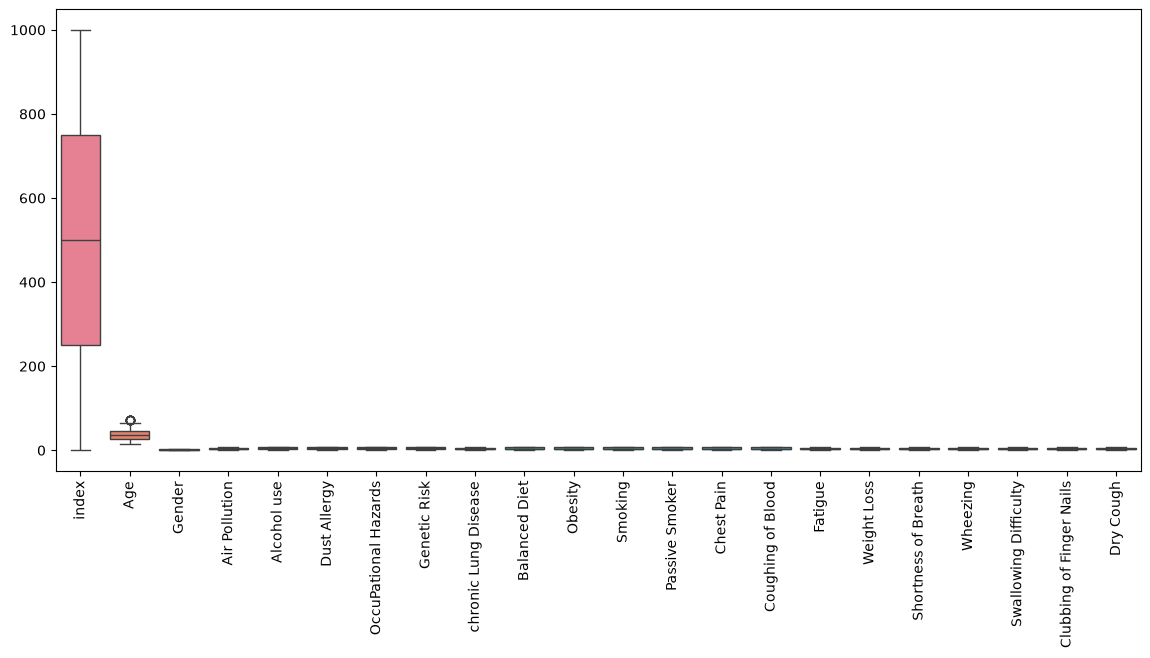

In [13]:
plt.figure(figsize=(14,6))
sns.boxplot(data=selected_df)
plt.xticks(rotation=90)
plt.show()